## E-Commerce Sales Analysis Using Python and SQL

## About This Project
In this project I have analyzed a real-world e-commerce dataset 
from a Brazilian company called Olist. The dataset contains more 
than 100,000 orders placed between 2016 and 2018.

I have used Python to load and clean the data, SQL to answer 
important business questions, and Matplotlib and Seaborn to 
create charts and graphs for better understanding.

## Dataset
- Name    : Brazilian E-Commerce Public Dataset by Olist
- Source  : Kaggle
- Size    : 100,000+ orders
- Tables  : 9 tables (orders, customers, sellers, products, 
            payments, reviews, order items, geolocation, 
            category translation)
- Period  : 2016 to 2018

## Tools and Technologies Used
- Python   : Loading and cleaning data
- Pandas   : Reading and processing data
- SQLite   : Storing data and writing SQL queries
- Matplotlib and Seaborn : Charts and visualizations

## Questions
1. What is the total revenue earned each month?
2. Which are the top 10 sellers by revenue?
3. Which product categories generate the most sales?
4. Which states have the highest number of customers?
5. How are orders distributed by their status?
6. Which product categories have the best review scores?
7. What is the month over month revenue growth percentage?
8. How do customers rank based on their total spending?

## SQL Concepts Used
- Basic   : JOIN, GROUP BY, ORDER BY, LIMIT, HAVING, 
            AVG, COUNT, SUM, ROUND
- Advanced: CTE (WITH clause), LAG() Window Function, 
            RANK() Window Function

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Library for data manipulation
import pandas as pd

# Library for database operations
import sqlite3

# Library for file and folder operations
import os

# Libraries for charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style to look clean
sns.set_theme(style='whitegrid')

# Set default chart size
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


### Load all CSV file into SQLite Database

In [2]:
# Give the path of the folder where all 9 CSV files are kept
folder_path = r"E:\Python and sql project\Olist_data"

# Connect to SQLite database
# SQLite will create the olist.db file automatically if it does not exist
conn = sqlite3.connect('olist.db')

# Loop through every file in the folder
for filename in os.listdir(folder_path):

    # Only process CSV files
    if filename.endswith('.csv'):

        # Remove .csv from filename to use as table name
        table_name = filename.replace('.csv', '')

        # Create full path by joining folder path and filename
        file_path = os.path.join(folder_path, filename)

        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)

        # Save the DataFrame as a table in SQLite
        df.to_sql(table_name, conn, if_exists='replace', index=False)

        print(f'Loaded: {table_name}  ({len(df)} rows)')

print('\nAll 9 files loaded successfully!')

Loaded: olist_customers_dataset  (99441 rows)
Loaded: olist_geolocation_dataset  (1000163 rows)
Loaded: olist_order_items_dataset  (112650 rows)
Loaded: olist_order_payments_dataset  (103886 rows)
Loaded: olist_order_reviews_dataset  (99224 rows)
Loaded: olist_orders_dataset  (99441 rows)
Loaded: olist_products_dataset  (32951 rows)
Loaded: olist_sellers_dataset  (3095 rows)
Loaded: product_category_name_translation  (71 rows)

All 9 files loaded successfully!


### Check all tables are loaded

In [3]:
# Get all table names from the SQLite database
cursor = conn.cursor()
cursor.execute("Select name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()

print(f"The tables in database: {len(tables)}")
print('-' * 40)

# Print each table name
for table in tables:
    print(f'  ->{table[0]}')

The tables in database: 9
----------------------------------------
  ->olist_customers_dataset
  ->olist_geolocation_dataset
  ->olist_order_items_dataset
  ->olist_order_payments_dataset
  ->olist_order_reviews_dataset
  ->olist_orders_dataset
  ->olist_products_dataset
  ->olist_sellers_dataset
  ->product_category_name_translation


### Data Cleaning

In [4]:
# Load the orders table into pandas
orders = pd.read_sql('SELECT * FROM olist_orders_dataset', conn)

# Check the shape of the table (rows and columns)
print('Shape of orders table:')
print(f'  Rows    :{orders.shape[0]}')
print(f'  Columns :{orders.shape[1]}')
print()

Shape of orders table:
  Rows    :99441
  Columns :8



In [5]:
# Check for missing values in each column
print('Missing values in each column:')
print(orders.isnull().sum())
print()

Missing values in each column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64



In [6]:
# Check for duplicate rows
print('Order status counts:')
print(orders['order_status'].value_counts())

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


### SQL Queries

<b> Question: </b> What is the total revenue earned each month?

In [7]:
# SQL query to get total revenue per month
query1 = """
    SELECT
    strftime('%Y-%m', o.order_purchase_timestamp) AS month,
    ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
    FROM olist_orders_dataset o
    JOIN olist_order_items_dataset oi
    ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY month
    ORDER BY month
"""

# Run query and save result in a DataFrame
df1 = pd.read_sql(query1, conn)

print('Monthly Revenue:')
print(df1)
print()

Monthly Revenue:
      month  total_revenue  total_orders
0   2016-09         143.46             1
1   2016-10       46490.66           265
2   2016-12          19.62             1
3   2017-01      127482.37           750
4   2017-02      271239.32          1653
5   2017-03      414330.95          2546
6   2017-04      390812.40          2303
7   2017-05      566851.40          3546
8   2017-06      490050.37          3135
9   2017-07      566299.08          3872
10  2017-08      645832.36          4193
11  2017-09      701077.49          4150
12  2017-10      751117.01          4478
13  2017-11     1153364.20          7289
14  2017-12      843078.29          5513
15  2018-01     1077887.46          7069
16  2018-02      966168.41          6555
17  2018-03     1120598.24          7003
18  2018-04     1132878.93          6798
19  2018-05     1128774.52          6749
20  2018-06     1011978.29          6099
21  2018-07     1027807.28          6159
22  2018-08      985491.64          6351

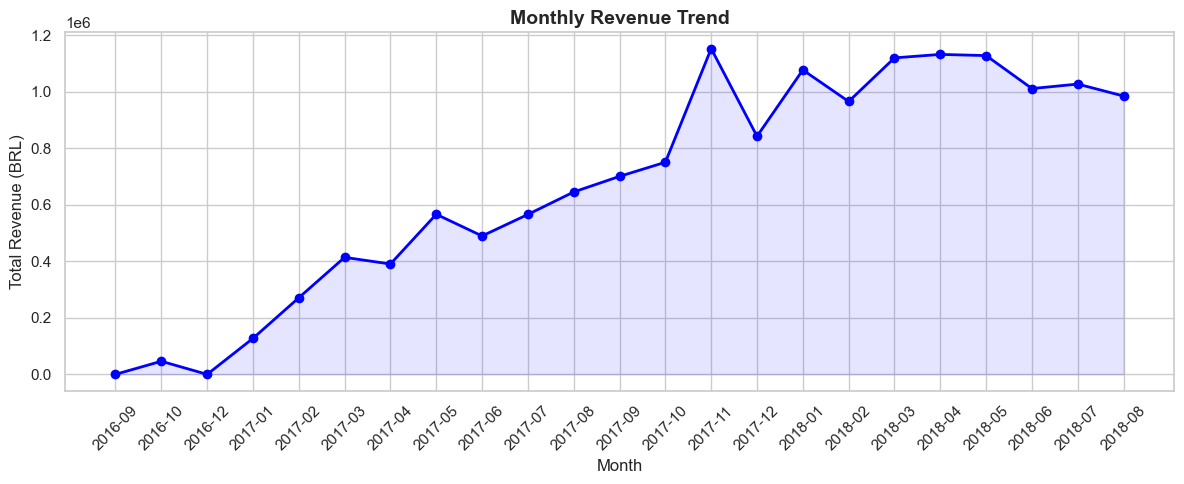

Best month: 2017-11
Total revenue: R$15,419,773.75



In [8]:
# Plot monthly revenue as a line chart
plt.figure(figsize=(12,5))
plt.plot(df1['month'], df1['total_revenue'], color='blue', marker='o', linewidth=2)
plt.fill_between(df1['month'], df1['total_revenue'], alpha=0.1, color='blue')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Best month: {df1.loc[df1["total_revenue"].idxmax(), "month"]}')
print(f"Total revenue: R${df1["total_revenue"].sum():,.2f}")
print()

<b> Question: </b> Which are the top 10 sellers by revenue?

In [9]:
# Query to find top 10 sellers by revenue
query2 = """
    SELECT
        s.seller_id,
        s.seller_city,
        s.seller_state,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price + oi.freight_value), 2) AS total_revenue
    FROM olist_sellers_dataset s
    JOIN olist_order_items_dataset oi
        ON s.seller_id = oi.seller_id
    JOIN olist_orders_dataset o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY s.seller_id
    ORDER BY total_revenue DESC
    LIMIT 10
"""

df2 = pd.read_sql(query2, conn)

# Shorten seller_id for display
df2['seller_short'] = df2['seller_id'].str[:8] + '...'

print('Top 10 Sellers by Revenue:')
print(df2[['seller_short', 'seller_city', 'seller_state', 'total_orders', 'total_revenue']])

Top 10 Sellers by Revenue:
  seller_short       seller_city seller_state  total_orders  total_revenue
0  4869f7a5...           guariba           SP          1124      247007.06
1  7c67e144...   itaquaquecetuba           SP           973      237806.69
2  4a3ca931...          ibitinga           SP          1772      231220.43
3  53243585...  lauro de freitas           BA           348      230797.02
4  fa1c13f2...            sumare           SP           578      200833.50
5  da8622b1...        piracicaba           SP          1311      184706.78
6  7e93a43e...           barueri           SP           319      171973.55
7  1025f0e2...         sao paulo           SP           910      171924.96
8  7a67c85e...         sao paulo           SP          1145      160278.52
9  955fee92...         sao paulo           SP          1261      156606.48


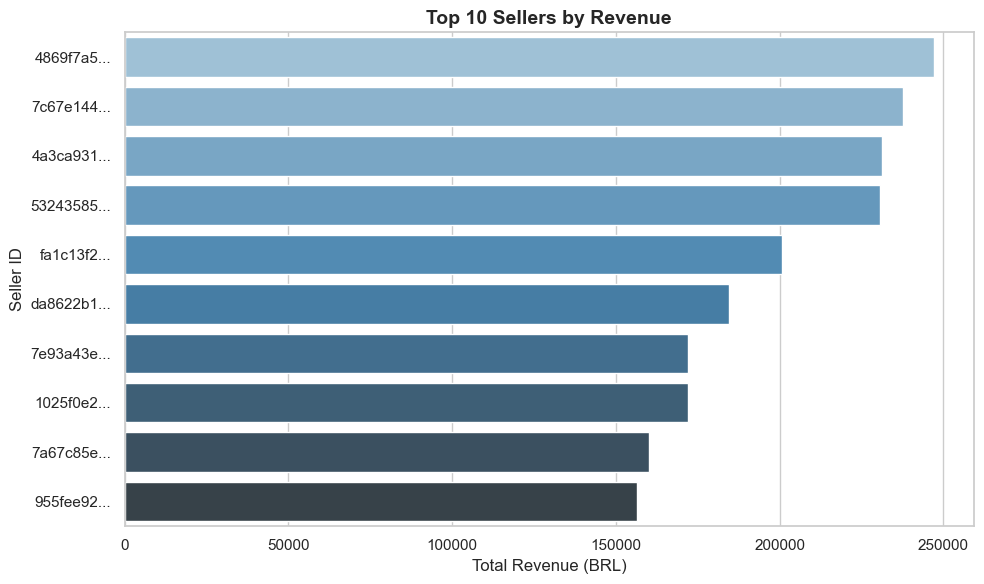

In [10]:
# Plot top 10 sellers as horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df2, x='total_revenue', y='seller_short', palette='Blues_d')
plt.title('Top 10 Sellers by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()

<b> Question: </b> Which product categories generate the most sales?

In [11]:
query3 = """
    SELECT
        COALESCE(t.product_category_name_english,
        p.product_category_name, 'Unknown') AS category,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price), 2) AS total_revenue
    FROM olist_orders_dataset o
    JOIN olist_order_items_dataset oi
        ON o.order_id = oi.order_id
    JOIN olist_products_dataset p
        ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 10
"""

df3 = pd.read_sql(query3, conn)
print('Top 10 Product Categories:')
print(df3)

Top 10 Product Categories:
                category  total_orders  total_revenue
0          health_beauty          8647     1233131.72
1          watches_gifts          5495     1166176.98
2         bed_bath_table          9272     1023434.76
3         sports_leisure          7530      954852.55
4  computers_accessories          6530      888724.61
5        furniture_decor          6307      711927.69
6             housewares          5743      615628.69
7             cool_stuff          3559      610204.10
8                   auto          3810      578966.65
9                   toys          3804      471286.48


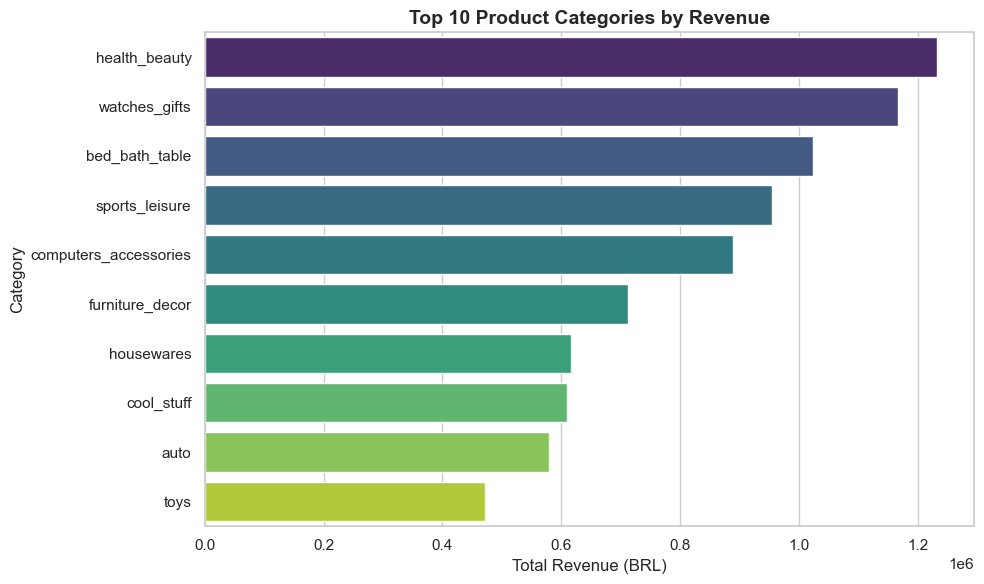

In [12]:
# Plot top categories
plt.figure(figsize=(10, 6))
sns.barplot(data=df3, x='total_revenue', y='category', palette='viridis')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

<b> Question: </b> Which states have the highest number of customers?

In [13]:
query4 = """
    SELECT
    customer_state,
    COUNT(DISTINCT customer_unique_id) AS total_customers
    FROM olist_customers_dataset
    GROUP BY customer_state
    ORDER BY total_customers DESC
    LIMIT 10
"""

df4 = pd.read_sql(query4, conn)
print('Top 10 States by Customers:')
print(df4)

Top 10 States by Customers:
  customer_state  total_customers
0             SP            40302
1             RJ            12384
2             MG            11259
3             RS             5277
4             PR             4882
5             SC             3534
6             BA             3277
7             DF             2075
8             ES             1964
9             GO             1952


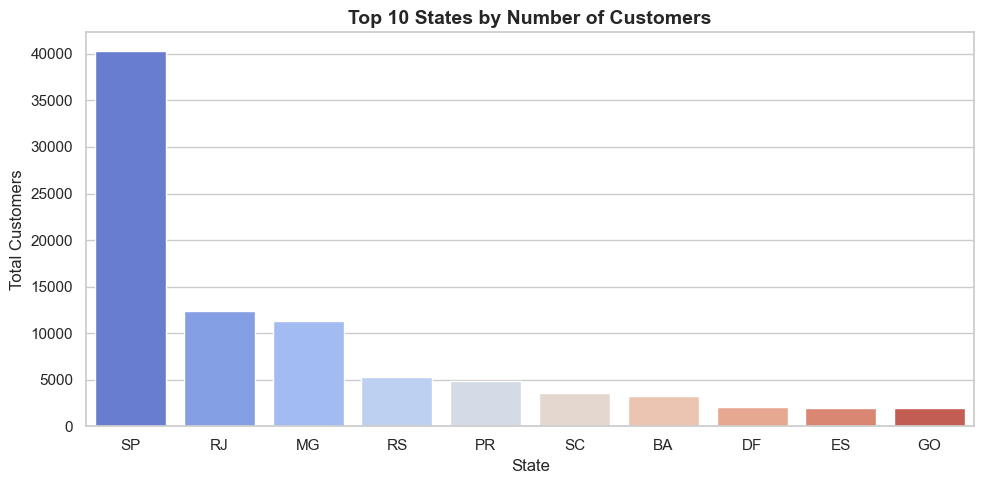

In [14]:
# Plot as bar chart
plt.figure(figsize=(10, 5))
sns.barplot(data=df4, x='customer_state', y='total_customers', palette='coolwarm')
plt.title('Top 10 States by Number of Customers', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Customers')
plt.tight_layout()
plt.show()

<b> Question: </b> How are orders distributed by their status?

In [15]:
# Simple query to count orders by status
query5 = """
    SELECT
        order_status,
        COUNT(*) AS total_orders
        FROM olist_orders_dataset
        GROUP BY order_status
        ORDER BY total_orders DESC
"""

df5 = pd.read_sql(query5, conn)
print('Order Status Breakdown:')
print(df5)

Order Status Breakdown:
  order_status  total_orders
0    delivered         96478
1      shipped          1107
2     canceled           625
3  unavailable           609
4     invoiced           314
5   processing           301
6      created             5
7     approved             2


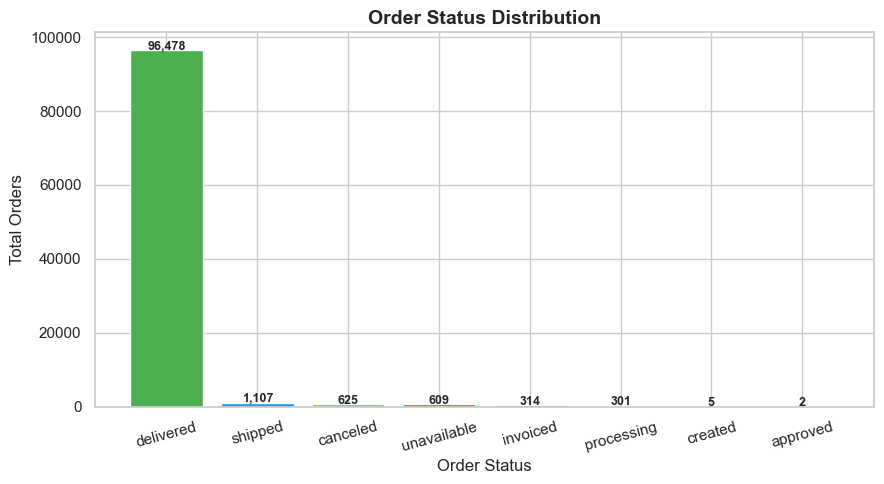

In [16]:
plt.figure(figsize=(9, 5))

colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336', 
          '#9C27B0', '#795548', '#607D8B']

bars = plt.bar(df5['order_status'], df5['total_orders'], 
               color=colors[:len(df5)])

# Add exact number on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 100,
        f'{int(height):,}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Order Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Order Status')
plt.ylabel('Total Orders')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<b> Question: </b> Which product categories have the best review scores?

In [17]:
# Query to get average review score per category
query6 = """
    SELECT
        COALESCE(t.product_category_name_english,
        p.product_category_name,
        'Unknown') AS category,
        ROUND(AVG(r.review_score), 2) AS avg_review_score,
        COUNT(r.review_id) AS total_reviews
    FROM olist_order_reviews_dataset r
    JOIN olist_orders_dataset o
        ON r.order_id = o.order_id
    JOIN olist_order_items_dataset oi
        ON o.order_id = oi.order_id
    JOIN olist_products_dataset p
        ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation t
        ON p.product_category_name = t.product_category_name
    GROUP BY category
    HAVING total_reviews > 100
    ORDER BY avg_review_score DESC
    LIMIT 10
"""

df6 = pd.read_sql(query6, conn)
print('Top 10 Categories by Review Score:')
print(df6)

Top 10 Categories by Review Score:
                 category  avg_review_score  total_reviews
0  books_general_interest              4.45            549
1         books_technical              4.37            266
2     luggage_accessories              4.32           1088
3              food_drink              4.32            279
4           fashion_shoes              4.23            261
5                    food              4.22            495
6              stationery              4.19           2507
7                pet_shop              4.19           1939
8         home_appliances              4.17            806
9               computers              4.17            200


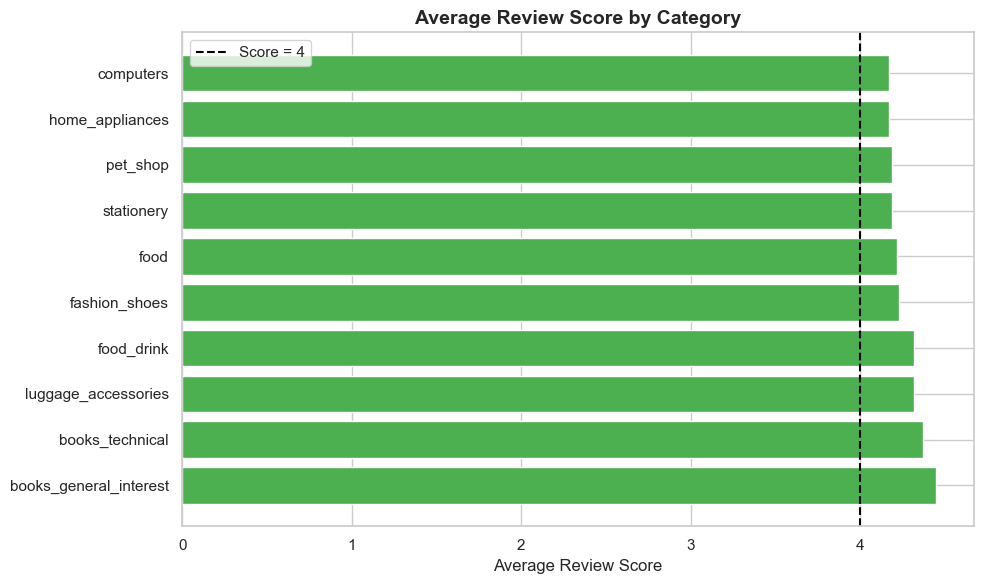

In [18]:
# Plot review scores
plt.figure(figsize=(10, 6))
colors = ['#4CAF50' if s >= 4 else '#FF9800' if s >= 3 else '#F44336'
          for s in df6['avg_review_score']]
plt.barh(df6['category'], df6['avg_review_score'], color=colors)
plt.axvline(x=4, color='black', linestyle='--', label='Score = 4')
plt.title('Average Review Score by Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Review Score')
plt.legend()
plt.tight_layout()
plt.show()

<b> Question: </b> What is the month over month revenue growth percentage?

In [19]:
# Advanced Query using CTE + LAG Window Function
query7 = """
    WITH monthly_revenue AS (
        SELECT
            strftime('%Y-%m', o.order_purchase_timestamp) AS month,
            ROUND(SUM(oi.price + oi.freight_value), 2)    AS revenue
        FROM olist_orders_dataset o
        JOIN olist_order_items_dataset oi
            ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY month
    )
    SELECT
        month,
        revenue,
        LAG(revenue) OVER (ORDER BY month)  AS prev_month_revenue,
        ROUND(
            (revenue - LAG(revenue) OVER (ORDER BY month)) * 100.0
            / LAG(revenue) OVER (ORDER BY month)
        , 2)                                AS growth_percent
    FROM monthly_revenue
    ORDER BY month
"""

df7 = pd.read_sql(query7, conn)

# Remove first row because there is no previous month for it
df7 = df7.dropna()

print('Month over Month Revenue Growth:')
print(df7)

Month over Month Revenue Growth:
      month     revenue  prev_month_revenue  growth_percent
1   2016-10    46490.66              143.46        32306.71
2   2016-12       19.62            46490.66          -99.96
3   2017-01   127482.37               19.62       649657.24
4   2017-02   271239.32           127482.37          112.77
5   2017-03   414330.95           271239.32           52.75
6   2017-04   390812.40           414330.95           -5.68
7   2017-05   566851.40           390812.40           45.04
8   2017-06   490050.37           566851.40          -13.55
9   2017-07   566299.08           490050.37           15.56
10  2017-08   645832.36           566299.08           14.04
11  2017-09   701077.49           645832.36            8.55
12  2017-10   751117.01           701077.49            7.14
13  2017-11  1153364.20           751117.01           53.55
14  2017-12   843078.29          1153364.20          -26.90
15  2018-01  1077887.46           843078.29           27.85
16  201

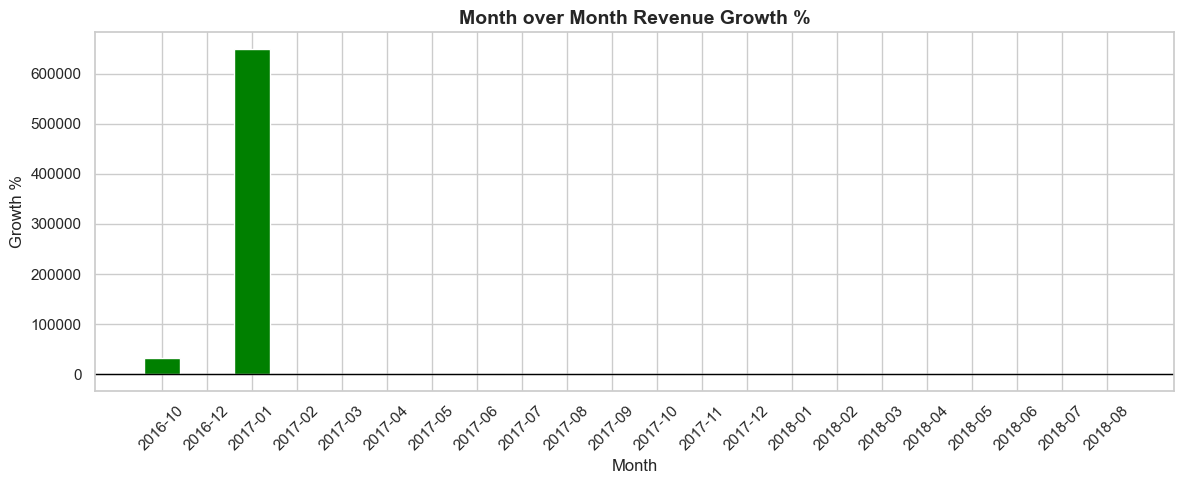

In [20]:
# Plot growth percentage — green for positive, red for negative
plt.figure(figsize=(12, 5))
colors = ['green' if g >= 0 else 'red' for g in df7['growth_percent']]
plt.bar(df7['month'], df7['growth_percent'], color=colors)
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Month over Month Revenue Growth %', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b> Question: </b> How do customers rank based on their total spending?

In [21]:
# Advanced Query using CTE + RANK Window Function
query8 = """
    WITH customer_spend AS (
        SELECT
            c.customer_unique_id,
            c.customer_city,
            c.customer_state,
            COUNT(DISTINCT o.order_id) AS total_orders,
            ROUND(SUM(oi.price + oi.freight_value), 2) AS total_spent
        FROM olist_customers_dataset c
        JOIN olist_orders_dataset o
            ON c.customer_id = o.customer_id
        JOIN olist_order_items_dataset oi
            ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    )
    SELECT
        RANK() OVER (ORDER BY total_spent DESC) AS customer_rank,
        customer_unique_id,
        customer_city,
        customer_state,
        total_orders,
        total_spent
    FROM customer_spend
    ORDER BY customer_rank
    LIMIT 10
"""

df8 = pd.read_sql(query8, conn)

# Shorten customer ID for display
df8['customer_short'] = df8['customer_unique_id'].str[:10] + '...'

print('Top 10 Customers by Total Spending:')
print(df8[['customer_rank', 'customer_short', 'customer_city',
           'customer_state', 'total_orders', 'total_spent']])

Top 10 Customers by Total Spending:
   customer_rank customer_short   customer_city customer_state  total_orders  \
0              1  0a0a92112b...  rio de janeiro             RJ             1   
1              2  da122df9ee...        araruama             RJ             2   
2              3  763c8b1c9c...      vila velha             ES             1   
3              4  dc4802a71e...    campo grande             MS             1   
4              5  459bef4868...         vitoria             ES             1   
5              6  ff4159b92c...         marilia             SP             1   
6              7  4007669dec...     divinopolis             MG             1   
7              8  eebb5dda14...            maua             SP             1   
8              9  48e1ac109d...     joao pessoa             PB             1   
9             10  c8460e4251...    porto alegre             RS             4   

   total_spent  
0     13664.08  
1      7571.63  
2      7274.88  
3      6929.31 

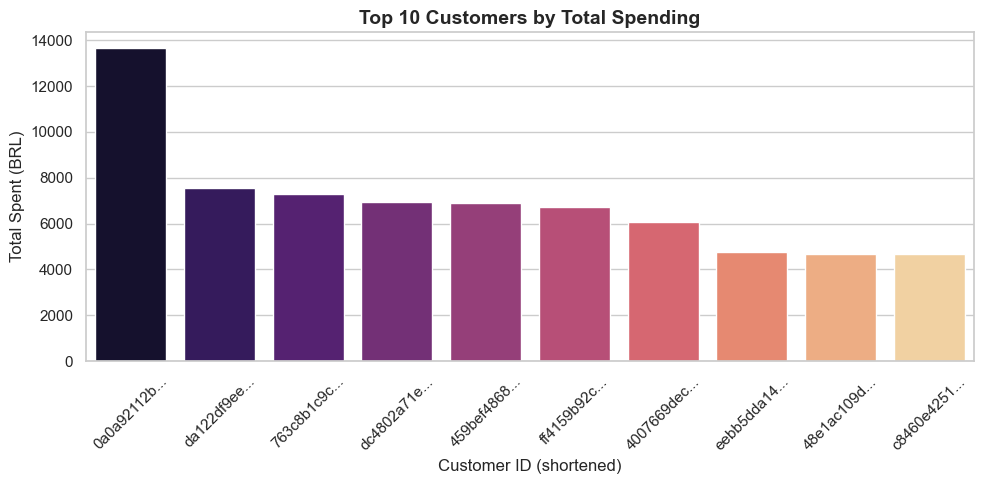

In [22]:
# Plot top 10 customers by spending
plt.figure(figsize=(10, 5))
sns.barplot(data=df8, x='customer_short', y='total_spent', palette='magma')
plt.title('Top 10 Customers by Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID (shortened)')
plt.ylabel('Total Spent (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<b> Question: </b> A summary of all key numbers from the analysis.

In [23]:
# Collect all key business numbers in one place

total_revenue = pd.read_sql("""
    SELECT ROUND(SUM(oi.price + oi.freight_value), 2) AS val
    FROM olist_orders_dataset o
    JOIN olist_order_items_dataset oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
""", conn)['val'][0]

total_orders = pd.read_sql("""
    SELECT COUNT(*) AS val FROM olist_orders_dataset
    WHERE order_status = 'delivered'
""", conn)['val'][0]

total_customers = pd.read_sql("""
    SELECT COUNT(DISTINCT customer_unique_id) AS val
    FROM olist_customers_dataset
""", conn)['val'][0]

total_sellers = pd.read_sql("""
    SELECT COUNT(DISTINCT seller_id) AS val
    FROM olist_sellers_dataset
""", conn)['val'][0]

avg_review = pd.read_sql("""
    SELECT ROUND(AVG(review_score), 2) AS val
    FROM olist_order_reviews_dataset
""", conn)['val'][0]

# Print the summary
print('=' * 45)
print('         BUSINESS SUMMARY')
print('=' * 45)
print(f'  Total Revenue    : R$ {total_revenue:>12,.2f}')
print(f'  Total Orders     : {total_orders:>15,}')
print(f'  Total Customers  : {total_customers:>15,}')
print(f'  Total Sellers    : {total_sellers:>15,}')
print(f'  Avg Review Score : {avg_review:>15}')
print('=' * 45)

         BUSINESS SUMMARY
  Total Revenue    : R$ 15,419,773.75
  Total Orders     :          96,478
  Total Customers  :          96,096
  Total Sellers    :           3,095
  Avg Review Score :            4.09


## Conclusion

In this project I analyzed 100,000+ real e-commerce orders using Pythob and SQL.

<b> Key Findings: </b>
1. Revenue grew steadily from 2016 to 2018 with a peak in November (Black Friday).
2. Health & Beauty and Watches are the top selling product categories.
3. Sao Paulo (SP) has the highest number of customers.
4. Over 96% of orders were successfully delivered.
5. Most categories maintain a review score above 4 out of 5.

<b> SQL Concepts I Used: </b>
1. Basic:    JOIN, GROUP BY, ORDER BY, LIMIT, HAVING, AVG, COUNT, SUM
2. Advanced: CTE (WITH Clause), LAG() Window Function, RANK() Window Function